# 04 — Model Training & Comparison

**Goal:** Train 5 models, evaluate on test set, pick the best one for AutoResearch optimization and tournament simulation.

**Models:**
1. Logistic Regression (baseline)
2. Random Forest
3. XGBoost
4. Neural Network (MLP)
5. Ensemble (XGBoost + RF + LR voting)

**Metrics:** Accuracy, F1 (macro), Log Loss, Confusion Matrix  
**Split:** Time-based — train pre-2022 WC, test 2022 WC onwards  
**Input:** `data/processed/train.csv`, `data/processed/test.csv`  
**Output:** `models/` (saved models), `data/processed/model_comparison.csv`

In [5]:
%pip install xgboost

     ------------------------------------ 101.7/101.7 MB 375.3 kB/s eta 0:00:00
     ------------------------------------ 101.7/101.7 MB 329.2 kB/s eta 0:00:00
     ------------------------------------ 101.7/101.7 MB 373.0 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, log_loss,
    confusion_matrix, classification_report
)
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb

sns.set_theme(style="darkgrid")
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


## Step 1 — Load Data & Prepare Features

In [7]:
train = pd.read_csv(PROCESSED_DIR / "train.csv", parse_dates=["date"])
test  = pd.read_csv(PROCESSED_DIR / "test.csv",  parse_dates=["date"])

print(f"Train: {len(train):,} rows | Test: {len(test):,} rows")

# Feature columns — everything except metadata and targets
META_COLS = ['date', 'home_team', 'away_team', 'home_score', 'away_score',
             'tournament', 'tournament_category', 'neutral', 'outcome', 'goal_diff']

# Drop duplicate 'neutral' column that came from static features
# (neutral exists in both meta and static_features — keep only one)
all_cols = [c for c in train.columns if c not in META_COLS]
# Remove any extra columns added during feature engineering (outcome_num, elo_diff_bucket)
EXCLUDE = ['outcome_num', 'elo_diff_bucket']
FEATURE_COLS = [c for c in all_cols if c not in EXCLUDE]

print(f"\nFeature columns ({len(FEATURE_COLS)}):")
for c in FEATURE_COLS:
    print(f"  {c}")

Train: 35,304 rows | Test: 3,313 rows

Feature columns (45):
  home_elo_before
  away_elo_before
  elo_diff
  home_win_rate_5
  home_avg_scored_5
  home_avg_conceded_5
  home_pts_per_match_5
  home_matches_played_5
  home_win_rate_10
  home_avg_scored_10
  home_avg_conceded_10
  home_pts_per_match_10
  home_matches_played_10
  away_win_rate_5
  away_avg_scored_5
  away_avg_conceded_5
  away_pts_per_match_5
  away_matches_played_5
  away_win_rate_10
  away_avg_scored_10
  away_avg_conceded_10
  away_pts_per_match_10
  away_matches_played_10
  h2h_home_win_rate
  h2h_home_avg_scored
  h2h_home_avg_conceded
  h2h_total_meetings
  h2h_recent_win_rate
  neutral.1
  tournament_importance
  home_conf_UEFA
  home_conf_CAF
  home_conf_AFC
  home_conf_CONCACAF
  home_conf_CONMEBOL
  home_conf_OFC
  home_conf_UNKNOWN
  away_conf_UEFA
  away_conf_CAF
  away_conf_AFC
  away_conf_CONCACAF
  away_conf_CONMEBOL
  away_conf_OFC
  away_conf_UNKNOWN
  same_confederation


In [8]:
# Prepare X and y
X_train = train[FEATURE_COLS].values
X_test  = test[FEATURE_COLS].values
y_train = train['outcome'].values
y_test  = test['outcome'].values

# Label encode target: home_win=0, draw=1, away_win=2
le = LabelEncoder()
le.fit(['away_win', 'draw', 'home_win'])
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print(f"Classes: {le.classes_}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nClass distribution (train):")
for cls, count in zip(*np.unique(y_train, return_counts=True)):
    print(f"  {cls}: {count} ({count/len(y_train):.1%})")

# Compute class weights for imbalance handling
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=le.classes_, y=y_train)
class_weight_dict = dict(zip(le.classes_, class_weights))
class_weight_enc = dict(zip(le.transform(le.classes_), class_weights))
print(f"\nClass weights: {class_weight_dict}")

Classes: ['away_win' 'draw' 'home_win']
X_train shape: (35304, 45)
X_test shape:  (3313, 45)

Class distribution (train):
  away_win: 8586 (24.3%)
  draw: 7396 (20.9%)
  home_win: 19322 (54.7%)

Class weights: {'away_win': 1.370603307710226, 'draw': 1.5911303407247162, 'home_win': 0.6090466825380395}


In [9]:
# Scale features for LR and MLP (tree models don't need scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler for inference
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
joblib.dump(le, MODELS_DIR / 'label_encoder.pkl')
joblib.dump(FEATURE_COLS, MODELS_DIR / 'feature_cols.pkl')
print("Scaler, label encoder, feature cols saved.")

Scaler, label encoder, feature cols saved.


## Step 2 — Define Evaluation Helper

In [10]:
def evaluate_model(name, model, X_test, y_test_enc, le):
    """Evaluate a trained model and return metrics dict."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    acc   = accuracy_score(y_test_enc, y_pred)
    f1    = f1_score(y_test_enc, y_pred, average='macro')
    ll    = log_loss(y_test_enc, y_proba)
    cm    = confusion_matrix(y_test_enc, y_pred)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1 Macro:  {f1:.4f}")
    print(f"  Log Loss:  {ll:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_, digits=3))

    return {
        'model': name,
        'accuracy': round(acc, 4),
        'f1_macro': round(f1, 4),
        'log_loss': round(ll, 4),
        'confusion_matrix': cm
    }

results = []
print("Evaluation helper defined.")

Evaluation helper defined.


## Step 3 — Model 1: Logistic Regression (Baseline)

In [11]:
print("Training Logistic Regression...")
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=1.0,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=42
)
lr.fit(X_train_scaled, y_train_enc)
res_lr = evaluate_model('Logistic Regression', lr, X_test_scaled, y_test_enc, le)
results.append(res_lr)
joblib.dump(lr, MODELS_DIR / 'logistic_regression.pkl')
print("Saved logistic_regression.pkl")

Training Logistic Regression...

  Logistic Regression
  Accuracy:  0.5922
  F1 Macro:  0.5596
  Log Loss:  0.8730

  Classification Report:
              precision    recall  f1-score   support

    away_win      0.581     0.630     0.604       894
        draw      0.343     0.411     0.374       750
    home_win      0.755     0.654     0.701      1669

    accuracy                          0.592      3313
   macro avg      0.560     0.565     0.560      3313
weighted avg      0.615     0.592     0.601      3313

Saved logistic_regression.pkl


## Step 4 — Model 2: Random Forest

In [12]:
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train_enc)
res_rf = evaluate_model('Random Forest', rf, X_test, y_test_enc, le)
results.append(res_rf)
joblib.dump(rf, MODELS_DIR / 'random_forest.pkl')
print("Saved random_forest.pkl")

Training Random Forest...

  Random Forest
  Accuracy:  0.5916
  F1 Macro:  0.5497
  Log Loss:  0.8771

  Classification Report:
              precision    recall  f1-score   support

    away_win      0.584     0.604     0.594       894
        draw      0.321     0.361     0.340       750
    home_win      0.744     0.688     0.715      1669

    accuracy                          0.592      3313
   macro avg      0.550     0.551     0.550      3313
weighted avg      0.605     0.592     0.597      3313

Saved random_forest.pkl


## Step 5 — Model 3: XGBoost

In [13]:
print("Training XGBoost...")

# Compute sample weights from class weights
sample_weights = np.array([class_weight_enc[y] for y in y_train_enc])

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train_enc,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test_enc)],
    verbose=50
)
res_xgb = evaluate_model('XGBoost', xgb_model, X_test, y_test_enc, le)
results.append(res_xgb)
joblib.dump(xgb_model, MODELS_DIR / 'xgboost.pkl')
print("Saved xgboost.pkl")

Training XGBoost...
[0]	validation_0-mlogloss:1.08496


c:\Users\Yash\anaconda3\lib\site-packages\xgboost\training.py:200: UserWarning: [00:27:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-mlogloss:0.88341
[100]	validation_0-mlogloss:0.87327
[150]	validation_0-mlogloss:0.87129
[200]	validation_0-mlogloss:0.87051
[250]	validation_0-mlogloss:0.87038
[300]	validation_0-mlogloss:0.87074
[350]	validation_0-mlogloss:0.87115
[400]	validation_0-mlogloss:0.87136
[450]	validation_0-mlogloss:0.87160
[499]	validation_0-mlogloss:0.87112

  XGBoost
  Accuracy:  0.5777
  F1 Macro:  0.5401
  Log Loss:  0.8711

  Classification Report:
              precision    recall  f1-score   support

    away_win      0.574     0.602     0.588       894
        draw      0.309     0.365     0.335       750
    home_win      0.741     0.660     0.698      1669

    accuracy                          0.578      3313
   macro avg      0.541     0.542     0.540      3313
weighted avg      0.598     0.578     0.586      3313

Saved xgboost.pkl


## Step 6 — Model 4: Neural Network (MLP)

In [14]:
print("Training Neural Network (MLP)...")
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='adaptive',
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp.fit(X_train_scaled, y_train_enc)
print(f"Stopped at iteration: {mlp.n_iter_}")
res_mlp = evaluate_model('Neural Network (MLP)', mlp, X_test_scaled, y_test_enc, le)
results.append(res_mlp)
joblib.dump(mlp, MODELS_DIR / 'mlp.pkl')
print("Saved mlp.pkl")

Training Neural Network (MLP)...
Stopped at iteration: 15

  Neural Network (MLP)
  Accuracy:  0.6215
  F1 Macro:  0.4912
  Log Loss:  0.8357

  Classification Report:
              precision    recall  f1-score   support

    away_win      0.602     0.595     0.599       894
        draw      0.383     0.079     0.131       750
    home_win      0.645     0.880     0.744      1669

    accuracy                          0.621      3313
   macro avg      0.544     0.518     0.491      3313
weighted avg      0.574     0.621     0.566      3313

Saved mlp.pkl


## Step 7 — Model 5: Ensemble (Voting)

In [15]:
print("Training Ensemble (Soft Voting: XGBoost + RF + LR)...")

# VotingClassifier needs all estimators to use the same input
# XGBoost and RF use raw features, LR uses scaled — wrap LR in a pipeline
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        C=1.0,
        multi_class='multinomial',
        solver='lbfgs',
        random_state=42
    ))
])

ensemble = VotingClassifier(
    estimators=[
        ('xgb', xgb.XGBClassifier(
            n_estimators=500, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric='mlogloss', objective='multi:softprob',
            num_class=3, random_state=42, n_jobs=-1
        )),
        ('rf', RandomForestClassifier(
            n_estimators=500, max_depth=10, min_samples_leaf=10,
            class_weight='balanced', random_state=42, n_jobs=-1
        )),
        ('lr', lr_pipe)
    ],
    voting='soft',
    weights=[3, 2, 1]  # XGBoost weighted highest based on paper evidence
)
ensemble.fit(X_train, y_train_enc)
res_ensemble = evaluate_model('Ensemble (XGB+RF+LR)', ensemble, X_test, y_test_enc, le)
results.append(res_ensemble)
joblib.dump(ensemble, MODELS_DIR / 'ensemble.pkl')
print("Saved ensemble.pkl")

Training Ensemble (Soft Voting: XGBoost + RF + LR)...

  Ensemble (XGB+RF+LR)
  Accuracy:  0.6212
  F1 Macro:  0.5313
  Log Loss:  0.8333

  Classification Report:
              precision    recall  f1-score   support

    away_win      0.586     0.623     0.604       894
        draw      0.377     0.183     0.246       750
    home_win      0.682     0.817     0.744      1669

    accuracy                          0.621      3313
   macro avg      0.549     0.541     0.531      3313
weighted avg      0.587     0.621     0.593      3313

Saved ensemble.pkl


## Step 8 — Comparison Table

In [16]:
comparison = pd.DataFrame([{
    'Model': r['model'],
    'Accuracy': r['accuracy'],
    'F1 Macro': r['f1_macro'],
    'Log Loss': r['log_loss'],
} for r in results])

comparison = comparison.sort_values('Log Loss').reset_index(drop=True)
print("\nModel Comparison (sorted by Log Loss — lower is better):")
print(comparison.to_string(index=False))

best_model_name = comparison.iloc[0]['Model']
print(f"\nBest model: {best_model_name}")
print(f"Best log loss: {comparison.iloc[0]['Log Loss']}")

comparison.to_csv(PROCESSED_DIR / 'model_comparison.csv', index=False)
print("Saved model_comparison.csv")


Model Comparison (sorted by Log Loss — lower is better):
               Model  Accuracy  F1 Macro  Log Loss
Ensemble (XGB+RF+LR)    0.6212    0.5313    0.8333
Neural Network (MLP)    0.6215    0.4912    0.8357
             XGBoost    0.5777    0.5401    0.8711
 Logistic Regression    0.5922    0.5596    0.8730
       Random Forest    0.5916    0.5497    0.8771

Best model: Ensemble (XGB+RF+LR)
Best log loss: 0.8333
Saved model_comparison.csv


## Step 9 — Visualization

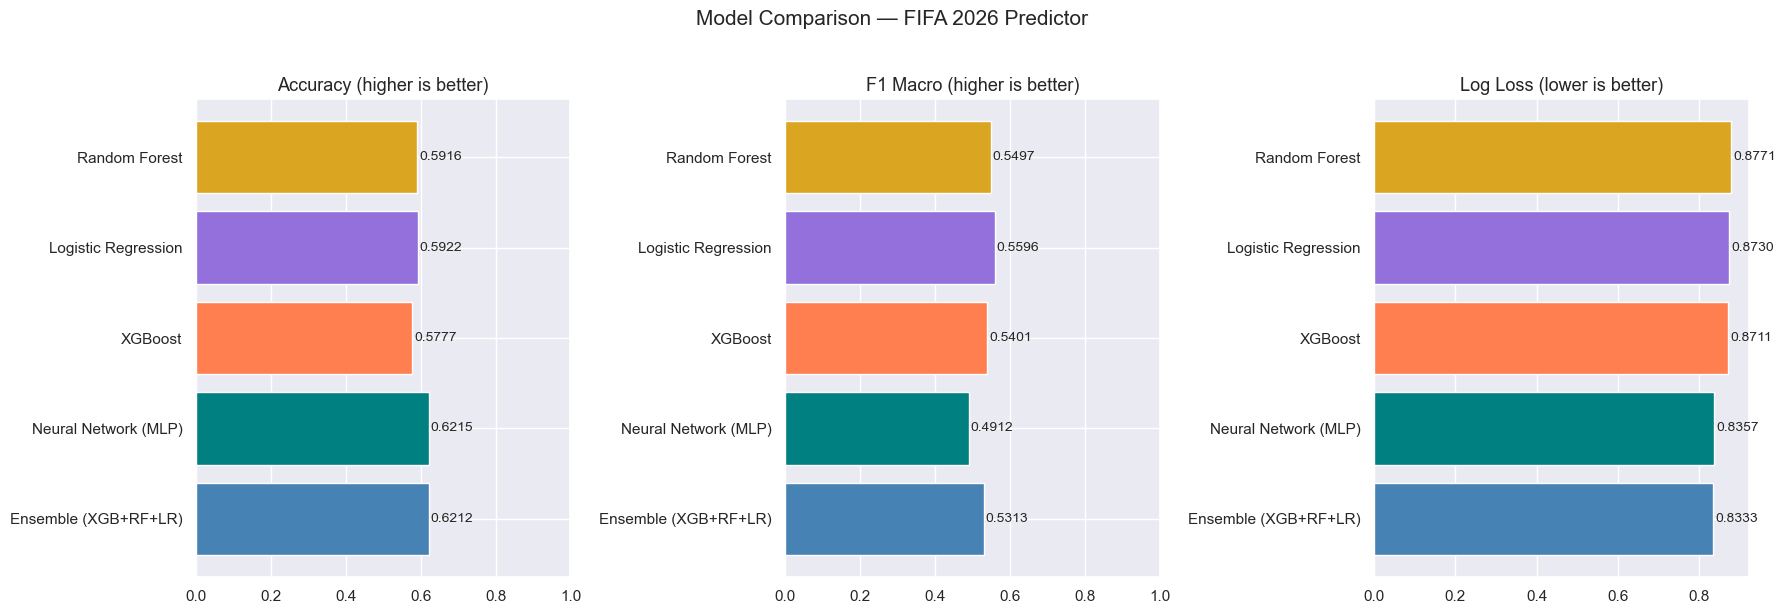

Saved images/04_model_comparison.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = comparison['Model']
colors = ['steelblue', 'teal', 'coral', 'mediumpurple', 'goldenrod'][:len(models)]

# Accuracy
axes[0].barh(models, comparison['Accuracy'], color=colors, edgecolor='white')
axes[0].set_title('Accuracy (higher is better)', fontsize=13)
axes[0].set_xlim(0, 1)
for i, v in enumerate(comparison['Accuracy']):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

# F1 Macro
axes[1].barh(models, comparison['F1 Macro'], color=colors, edgecolor='white')
axes[1].set_title('F1 Macro (higher is better)', fontsize=13)
axes[1].set_xlim(0, 1)
for i, v in enumerate(comparison['F1 Macro']):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

# Log Loss
axes[2].barh(models, comparison['Log Loss'], color=colors, edgecolor='white')
axes[2].set_title('Log Loss (lower is better)', fontsize=13)
for i, v in enumerate(comparison['Log Loss']):
    axes[2].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

plt.suptitle('Model Comparison — FIFA 2026 Predictor', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved images/04_model_comparison.png")

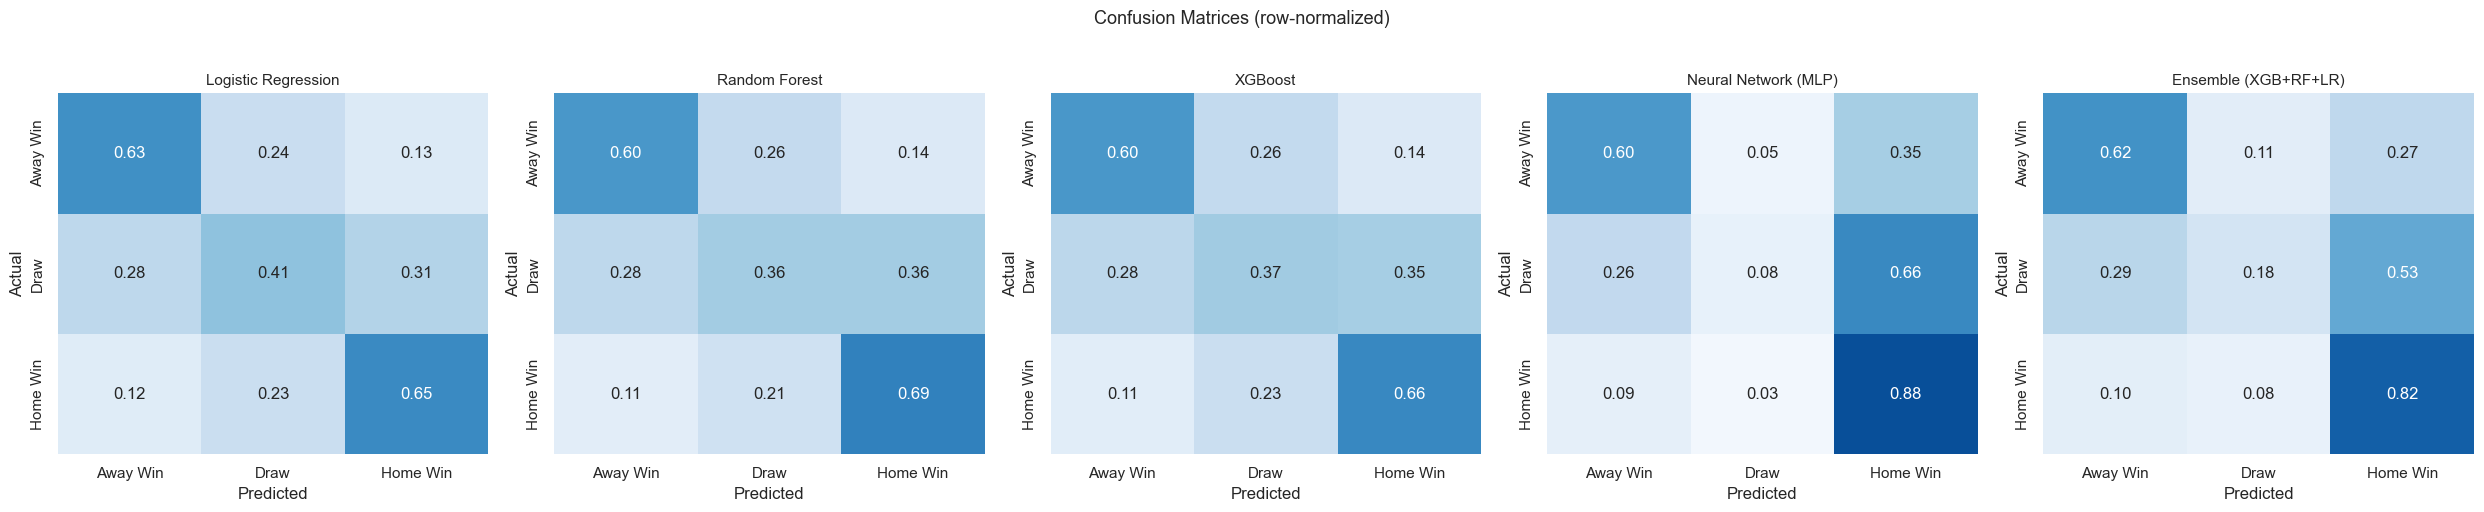

Saved images/04_confusion_matrices.png


In [18]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5))
class_labels = ['Away Win', 'Draw', 'Home Win']

for ax, r in zip(axes, results):
    cm = r['confusion_matrix']
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                cbar=False, vmin=0, vmax=1)
    ax.set_title(r['model'], fontsize=11)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices (row-normalized)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('images/04_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved images/04_confusion_matrices.png")

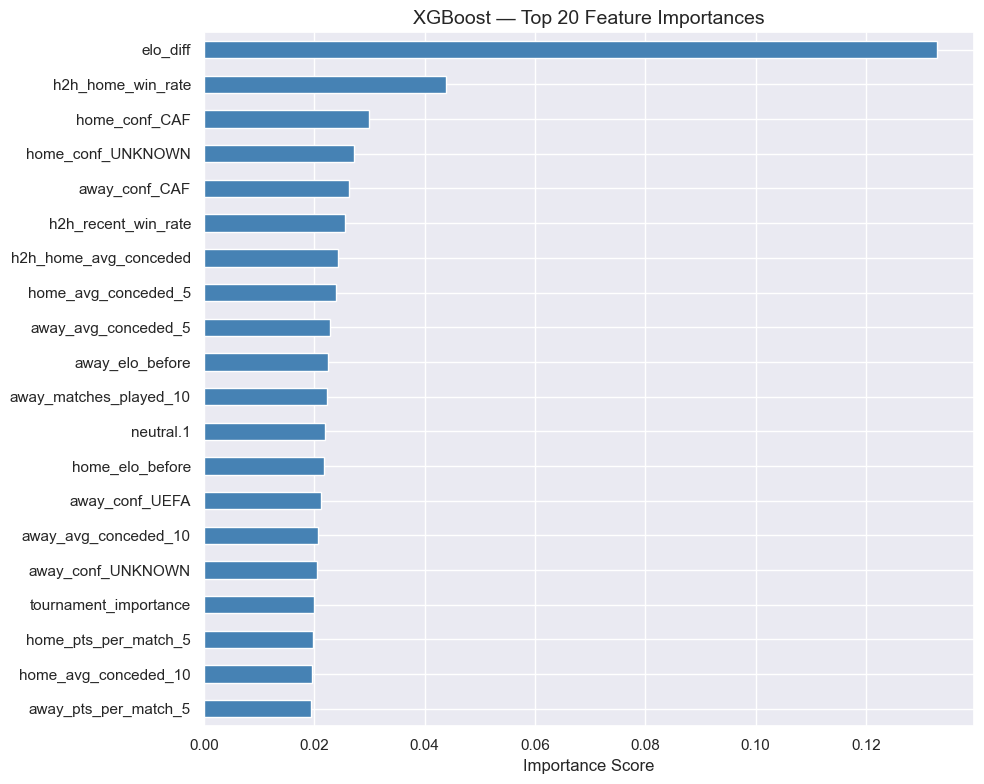

Saved images/04_feature_importance.png


In [19]:
# XGBoost feature importance
importances = pd.Series(
    xgb_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('XGBoost — Top 20 Feature Importances', fontsize=14)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('images/04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved images/04_feature_importance.png")

## Step 10 — 2022 WC Backtest

Specifically evaluate the best model on 2022 World Cup matches only — this is the closest proxy to what we'll be predicting in 2026.

In [20]:
# Pick best model based on log loss
model_map = {
    'Logistic Regression': (lr, X_test_scaled),
    'Random Forest': (rf, X_test),
    'XGBoost': (xgb_model, X_test),
    'Neural Network (MLP)': (mlp, X_test_scaled),
    'Ensemble (XGB+RF+LR)': (ensemble, X_test),
}

best_name = comparison.iloc[0]['Model']
best_model, best_X = model_map[best_name]

# Filter test set to 2022 WC matches only
wc_mask = test['tournament_category'] == 'world_cup'
wc_test = test[wc_mask].copy()
wc_indices = wc_test.index - test.index[0]  # relative indices into X_test
X_wc = best_X[wc_indices]
y_wc = y_test_enc[wc_indices]

y_wc_pred = best_model.predict(X_wc)
y_wc_proba = best_model.predict_proba(X_wc)

wc_acc  = accuracy_score(y_wc, y_wc_pred)
wc_f1   = f1_score(y_wc, y_wc_pred, average='macro')
wc_ll   = log_loss(y_wc, y_wc_proba)

print(f"2022 World Cup Backtest — {best_name}")
print(f"  Matches: {len(wc_test)}")
print(f"  Accuracy:  {wc_acc:.4f}")
print(f"  F1 Macro:  {wc_f1:.4f}")
print(f"  Log Loss:  {wc_ll:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_wc, y_wc_pred, target_names=le.classes_, digits=3))

# Show some predictions vs actual
wc_test = wc_test.reset_index(drop=True)
wc_test['predicted'] = le.inverse_transform(y_wc_pred)
wc_test['correct'] = wc_test['outcome'] == wc_test['predicted']
wc_test['home_win_prob'] = y_wc_proba[:, le.transform(['home_win'])[0]]
wc_test['draw_prob'] = y_wc_proba[:, le.transform(['draw'])[0]]
wc_test['away_win_prob'] = y_wc_proba[:, le.transform(['away_win'])[0]]

print(f"\nSample 2022 WC predictions:")
cols = ['home_team', 'away_team', 'home_score', 'away_score', 'outcome', 'predicted', 'correct', 'home_win_prob', 'draw_prob', 'away_win_prob']
print(wc_test[cols].head(15).to_string(index=False))

2022 World Cup Backtest — Ensemble (XGB+RF+LR)
  Matches: 90
  Accuracy:  0.5444
  F1 Macro:  0.4881
  Log Loss:  1.0253

Classification Report:
              precision    recall  f1-score   support

    away_win      0.407     0.524     0.458        21
        draw      0.545     0.261     0.353        23
    home_win      0.615     0.696     0.653        46

    accuracy                          0.544        90
   macro avg      0.523     0.493     0.488        90
weighted avg      0.549     0.544     0.531        90


Sample 2022 WC predictions:
    home_team    away_team  home_score  away_score  outcome predicted  correct  home_win_prob  draw_prob  away_win_prob
        Qatar      Ecuador           0           2 away_win  away_win     True       0.283803   0.352853       0.363344
      Senegal  Netherlands           0           2 away_win  away_win     True       0.214898   0.313185       0.471917
      England         Iran           6           2 home_win  home_win     True       

## Step 11 — Save Best Model & Summary

In [21]:
# Save best model with a clear name
joblib.dump(best_model, MODELS_DIR / 'best_model.pkl')

# Save metadata
import json
model_meta = {
    'best_model': best_name,
    'feature_cols': FEATURE_COLS,
    'classes': list(le.classes_),
    'needs_scaling': best_name in ['Logistic Regression', 'Neural Network (MLP)'],
    'train_size': len(train),
    'test_size': len(test),
    'split_date': '2022-11-20',
    'metrics': {
        'accuracy': float(comparison.iloc[0]['Accuracy']),
        'f1_macro': float(comparison.iloc[0]['F1 Macro']),
        'log_loss': float(comparison.iloc[0]['Log Loss']),
    },
    'wc2022_backtest': {
        'accuracy': round(wc_acc, 4),
        'f1_macro': round(wc_f1, 4),
        'log_loss': round(wc_ll, 4),
        'n_matches': len(wc_test)
    }
}
with open(MODELS_DIR / 'model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

print("=" * 55)
print("MODEL TRAINING SUMMARY")
print("=" * 55)
print(f"\nBest model: {best_name}")
print(f"Test accuracy:  {comparison.iloc[0]['Accuracy']}")
print(f"Test F1 Macro:  {comparison.iloc[0]['F1 Macro']}")
print(f"Test Log Loss:  {comparison.iloc[0]['Log Loss']}")
print(f"\n2022 WC Backtest accuracy: {round(wc_acc, 4)}")
print(f"\nSaved models:")
for f in sorted(MODELS_DIR.glob('*.pkl')):
    print(f"  {f.name}")
print(f"\nNext: Set up AutoResearch to beat log_loss of {comparison.iloc[0]['Log Loss']}")

MODEL TRAINING SUMMARY

Best model: Ensemble (XGB+RF+LR)
Test accuracy:  0.6212
Test F1 Macro:  0.5313
Test Log Loss:  0.8333

2022 WC Backtest accuracy: 0.5444

Saved models:
  best_model.pkl
  ensemble.pkl
  feature_cols.pkl
  label_encoder.pkl
  logistic_regression.pkl
  mlp.pkl
  random_forest.pkl
  scaler.pkl
  xgboost.pkl

Next: Set up AutoResearch to beat log_loss of 0.8333
